#### Import

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.models import GraphSAGE
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.utils.multiseed import run_multiseed

#### Load data

In [2]:
data, device = load_and_preprocess_data('../data/processed/elliptic_pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define training function for one seed

In [3]:
def run_single_gcn_seed(seed):
    set_seed(seed)
    print(f"GCN Train - Seed: {seed}")
    
    model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        aggregator_type='mean',
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=0.01,
        steps_per_epoch=1, 
        epochs=300,
        pct_start=0.1,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'../saved_models/graph_sage_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model, data, optimizer, criterion,
        scheduler=scheduler,
        save_path=save_path,
        num_epochs=300,
        patience=30,
        monitor_metric='f1_ill',
        clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GraphSAGE (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    print_test_evaluation(model, data, criterion, label=f"GraphSAGE Test - Seed: {seed}")
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    return test_metrics

#### Train with multi-seed

Start training GraphSAGE

GraphSAGE - Seed: 42
GCN Train - Seed: 42
Epoch 001: Train Loss=0.6963, Val Loss=0.6775, Train F1=0.1959, Val F1=0.1055, Gap=0.0905
Epoch 002: Train Loss=0.6675, Val Loss=0.6767, Train F1=0.2188, Val F1=0.1203, Gap=0.0985
Epoch 003: Train Loss=0.6493, Val Loss=0.6765, Train F1=0.2495, Val F1=0.1539, Gap=0.0955
Epoch 004: Train Loss=0.6230, Val Loss=0.6771, Train F1=0.2961, Val F1=0.1995, Gap=0.0966
Epoch 005: Train Loss=0.6178, Val Loss=0.6756, Train F1=0.3430, Val F1=0.2388, Gap=0.1042
Epoch 006: Train Loss=0.5698, Val Loss=0.6752, Train F1=0.3972, Val F1=0.2895, Gap=0.1077
Epoch 007: Train Loss=0.5384, Val Loss=0.6772, Train F1=0.4503, Val F1=0.3251, Gap=0.1253
Epoch 008: Train Loss=0.5108, Val Loss=0.6817, Train F1=0.4948, Val F1=0.3385, Gap=0.1563
Epoch 009: Train Loss=0.4816, Val Loss=0.6884, Train F1=0.5298, Val F1=0.3429, Gap=0.1869
Epoch 010: Train Loss=0.4498, Val Loss=0.6966, Train F1=0.5568, Val F1=0.3467, Gap=0.2101
Epoch 011: Train Loss=0.4229, Va

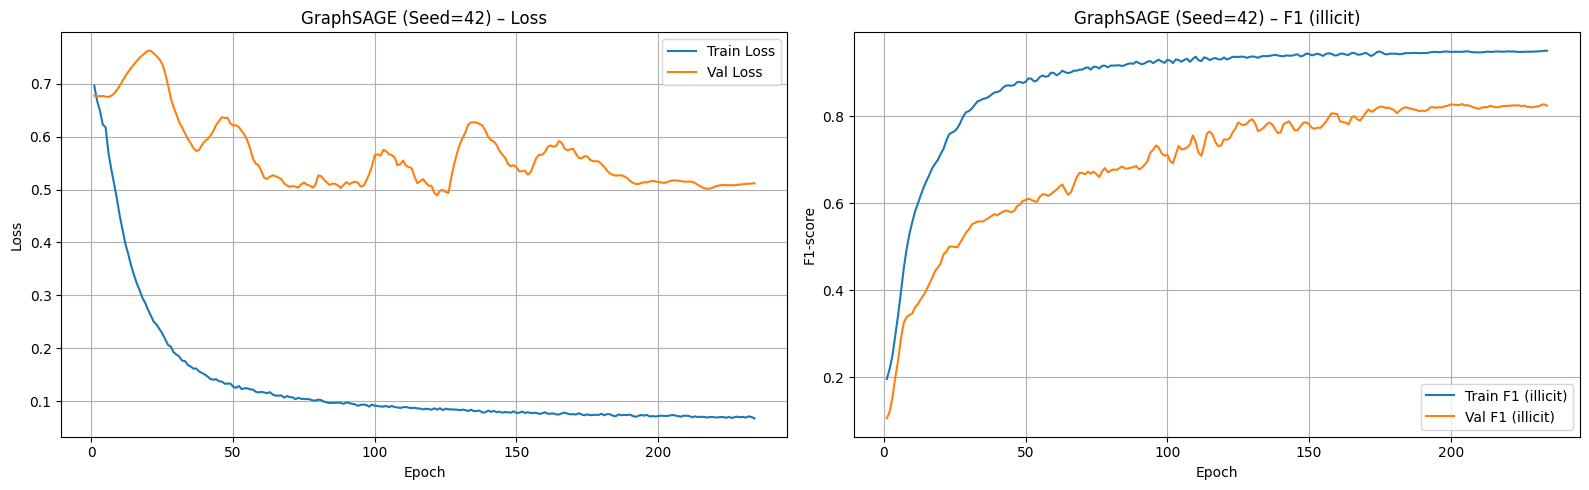

GraphSAGE Test - Seed: 42
  Loss          : 0.4907
  Accuracy      : 0.9509
  Precision(ill): 0.8135
  Recall(ill)   : 0.6369
  F1(illicit)   : 0.7144
  F1(macro)     : 0.8438
  AUC-PR        : 0.7459
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9621    0.9844    0.9731      5132
 Illicit (1)     0.8135    0.6369    0.7144       548

    accuracy                         0.9509      5680
   macro avg     0.8878    0.8106    0.8438      5680
weighted avg     0.9478    0.9509    0.9482      5680

Confusion Matrix:
[[5052   80]
 [ 199  349]]

GraphSAGE - Seed: 0
GCN Train - Seed: 0
Epoch 001: Train Loss=0.9663, Val Loss=1.8321, Train F1=0.1551, Val F1=0.0464, Gap=0.1086
Epoch 002: Train Loss=0.9902, Val Loss=0.8365, Train F1=0.1661, Val F1=0.0514, Gap=0.1148
Epoch 003: Train Loss=0.8287, Val Loss=0.6549, Train F1=0.1922, Val F1=0.0790, Gap=0.1133
Epoch 004: Train Loss=0.9206, Val Loss=0.6457, Train F1=0.2202, Val F1=0.0907, Gap=0.1295
Epo

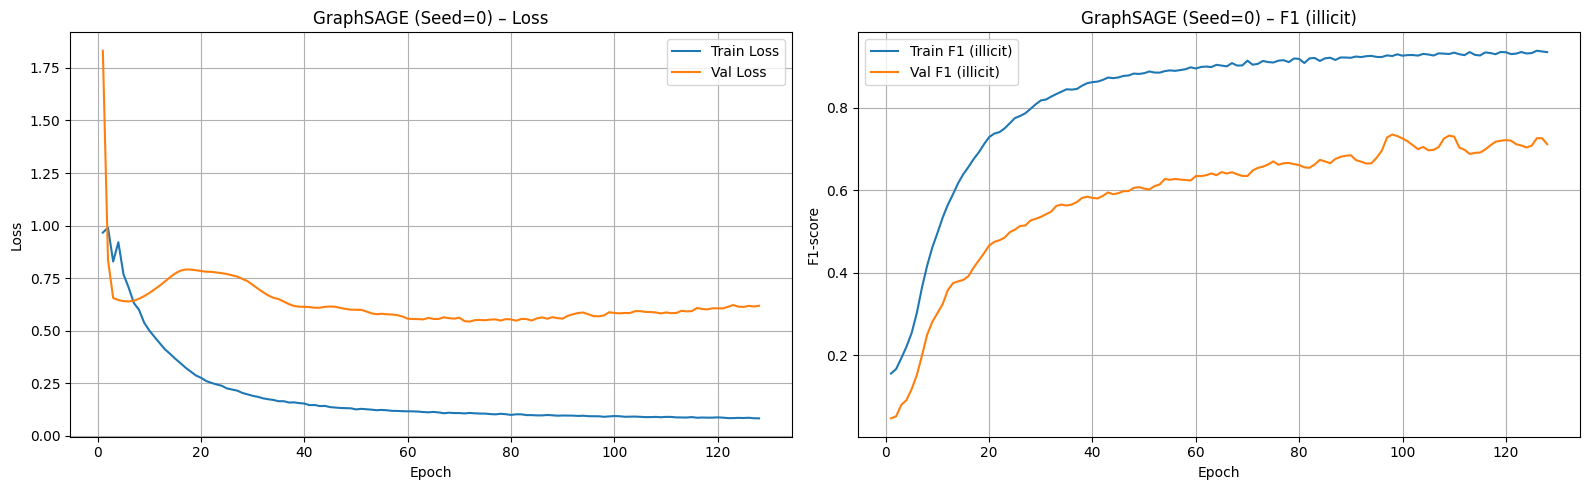

GraphSAGE Test - Seed: 0
  Loss          : 0.3893
  Accuracy      : 0.9502
  Precision(ill): 0.7849
  Recall(ill)   : 0.6661
  F1(illicit)   : 0.7206
  F1(macro)     : 0.8466
  AUC-PR        : 0.7410
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9649    0.9805    0.9726      5132
 Illicit (1)     0.7849    0.6661    0.7206       548

    accuracy                         0.9502      5680
   macro avg     0.8749    0.8233    0.8466      5680
weighted avg     0.9475    0.9502    0.9483      5680

Confusion Matrix:
[[5032  100]
 [ 183  365]]

GraphSAGE - Seed: 123
GCN Train - Seed: 123
Epoch 001: Train Loss=0.8215, Val Loss=0.7816, Train F1=0.2834, Val F1=0.1859, Gap=0.0975
Epoch 002: Train Loss=0.8052, Val Loss=0.7636, Train F1=0.3041, Val F1=0.1918, Gap=0.1123
Epoch 003: Train Loss=0.7688, Val Loss=0.7452, Train F1=0.3239, Val F1=0.2013, Gap=0.1226
Epoch 004: Train Loss=0.7259, Val Loss=0.7265, Train F1=0.3522, Val F1=0.2111, Gap=0.1411


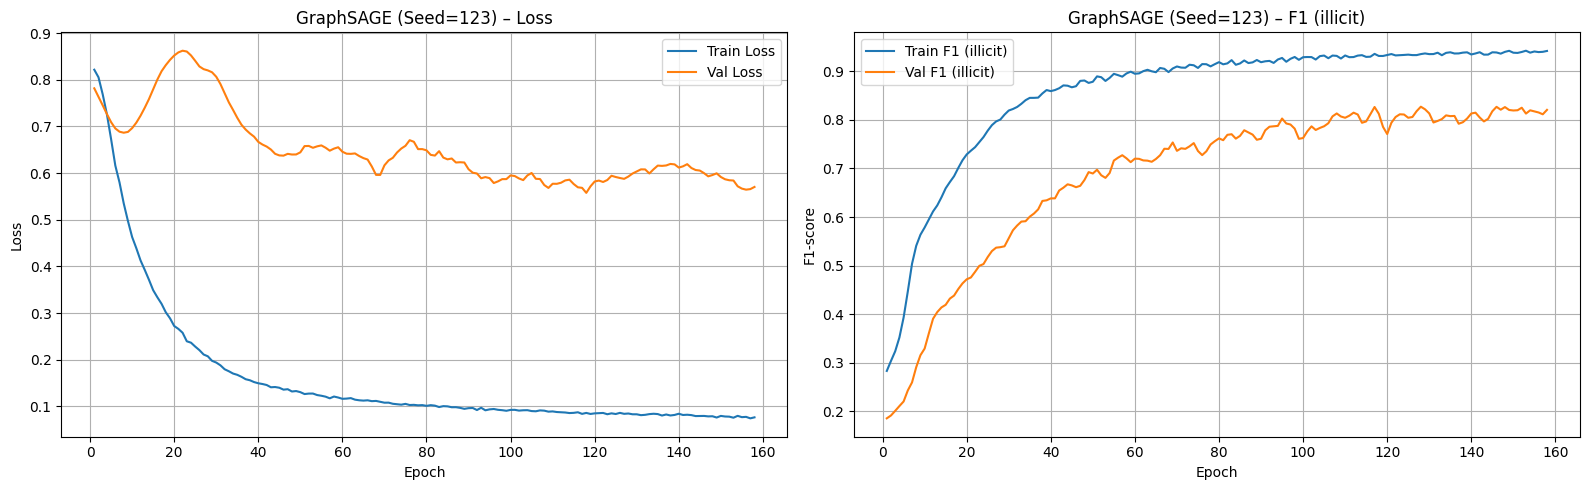

GraphSAGE Test - Seed: 123
  Loss          : 0.4518
  Accuracy      : 0.9532
  Precision(ill): 0.8422
  Recall(ill)   : 0.6332
  F1(illicit)   : 0.7229
  F1(macro)     : 0.8487
  AUC-PR        : 0.7611
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9618    0.9873    0.9744      5132
 Illicit (1)     0.8422    0.6332    0.7229       548

    accuracy                         0.9532      5680
   macro avg     0.9020    0.8103    0.8487      5680
weighted avg     0.9503    0.9532    0.9502      5680

Confusion Matrix:
[[5067   65]
 [ 201  347]]

 GraphSAGE multi-seed results
Loss       : 0.4439 ± 0.0418
Accuracy   : 0.9514 ± 0.0013
Precision_ill: 0.8136 ± 0.0234
Recall_ill : 0.6454 ± 0.0147
F1(illicit): 0.7193 ± 0.0036
F1_macro   : 0.8464 ± 0.0020
AUC-PR     : 0.7493 ± 0.0086


In [4]:
print("Start training GraphSAGE")
results = run_multiseed(run_single_gcn_seed, "GraphSAGE", seeds=[42, 0, 123])